In [1]:
# Import required libraries
import pandas as pd
import numpy as np

# For preprocessing text
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# For model building
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten

# For splitting dataset
from sklearn.model_selection import train_test_split

# For evaluation
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error

In [2]:
# -------------------------------
# STEP 1: Load Dataset
# -------------------------------

# Load your dataset
df = pd.read_csv('IMDB_dataset.csv', engine='python', encoding='latin1')

# Display first few rows
print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [3]:
# -------------------------------
# STEP 2: Data Preprocessing
# -------------------------------

# Convert sentiment labels to numerical values
# positive -> 1, negative -> 0
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Extract features (X) and labels (y)
X = df['review']
y = df['sentiment']

In [4]:
# -------------------------------
# STEP 3: Tokenization
# -------------------------------

# Convert text into numbers (important for neural networks)
# num_words limits vocabulary size (top frequent words)
tokenizer = Tokenizer(num_words=5000)

# Learn vocabulary from text
tokenizer.fit_on_texts(X)

# Convert text into sequences of integers
X_seq = tokenizer.texts_to_sequences(X)

In [5]:
# -------------------------------
# STEP 4: Padding
# -------------------------------

# Ensure all sequences have same length
# This is required for neural networks
max_len = 200

X_pad = pad_sequences(X_seq, maxlen=max_len)

In [6]:
# -------------------------------
# STEP 5: Train-Test Split
# -------------------------------

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X_pad, y, test_size=0.2, random_state=42
)

In [7]:
# -------------------------------
# STEP 6: Build Deep Neural Network
# -------------------------------

model = Sequential()

# Embedding layer:
# Converts word indices into dense vectors (word embeddings)
model.add(Embedding(input_dim=5000, output_dim=128, input_length=max_len))

# Flatten layer:
# Converts 2D embedding output into 1D vector
model.add(Flatten())

# Hidden layers:
# Learn complex patterns in data
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))

# Output layer:
# Sigmoid is used for binary classification
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [8]:
# -------------------------------
# STEP 7: Compile Model
# -------------------------------

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'mae', 'mse'])

In [9]:
# -------------------------------
# STEP 8: Train Model
# -------------------------------

results = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 70s 54ms/step - accuracy: 0.8324 - loss: 0.3649 - mae: 0.2310 - mse: 0.1161 - val_accuracy: 0.8773 - val_loss: 0.2843 - val_mae: 0.1732 - val_mse: 0.0873
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 69s 55ms/step - accuracy: 0.9578 - loss: 0.1147 - mae: 0.0652 - mse: 0.0320 - val_accuracy: 0.8588 - val_loss: 0.3704 - val_mae: 0.1646 - val_mse: 0.1062
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 69s 55ms/step - accuracy: 0.9891 - loss: 0.0304 - mae: 0.0171 - mse: 0.0082 - val_accuracy: 0.8591 - val_loss: 0.5627 - val_mae: 0.1474 - val_mse: 0.1183
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 70s 56ms/step - accuracy: 0.9930 - loss: 0.0206 - mae: 0.0107 - mse: 0.0055 - val_accuracy: 0.8569 - val_loss: 0.6680 - val_mae: 0.1490 - val_mse: 0.1244
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 56ms/step - accuracy: 0.9935 - loss: 0.0184 - mae: 0.0095 - mse: 0.0049 - val_accuracy: 0.8633 - val_loss: 0.5773 - val_mae: 0.1448 - val_mse: 0.1168


dict_keys(['accuracy', 'loss', 'mae', 'mse', 'val_accuracy', 'val_loss', 'val_mae', 'val_mse'])


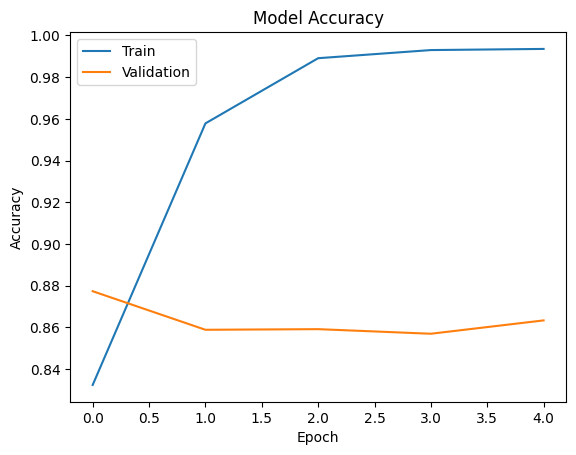

In [10]:
import matplotlib.pyplot as plt

# Check available metrics
print(results.history.keys())

# -------------------------------
# ACCURACY GRAPH
# -------------------------------
plt.plot(results.history['accuracy'])
plt.plot(results.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

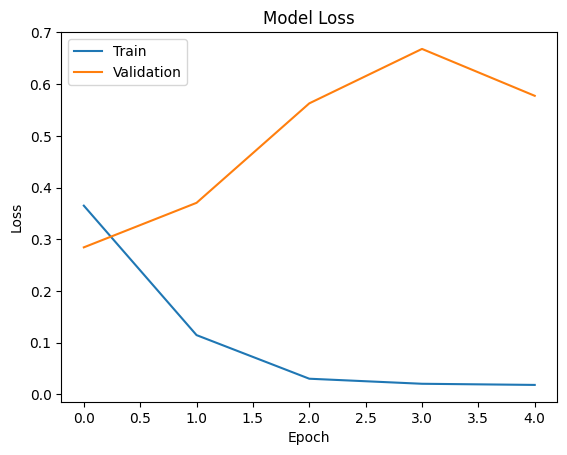

In [11]:
# -------------------------------
# LOSS GRAPH
# -------------------------------
plt.plot(results.history['loss'])
plt.plot(results.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

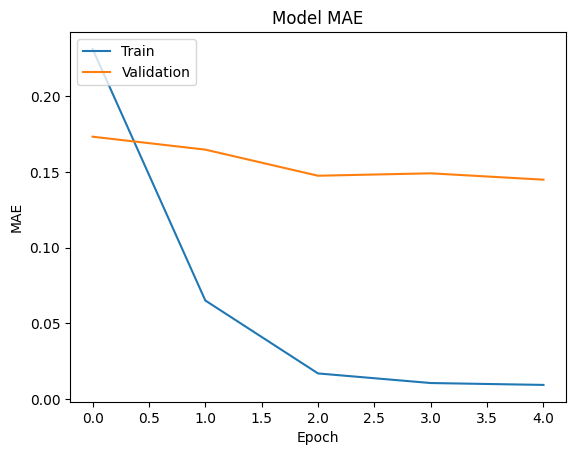

In [12]:
# -------------------------------
# MAE GRAPH
# -------------------------------
plt.plot(results.history['mae'])
plt.plot(results.history['val_mae'])
plt.title('Model MAE')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

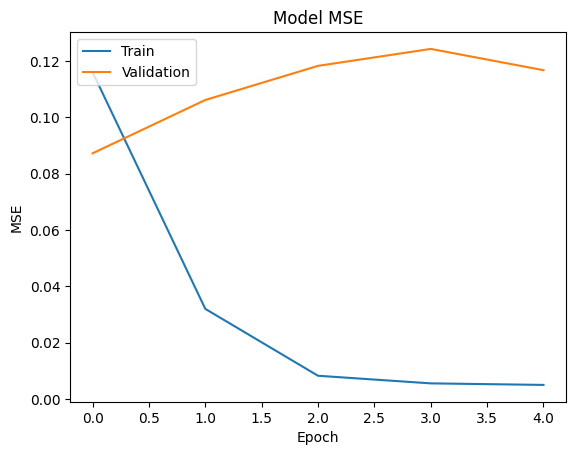

In [13]:
# -------------------------------
# MSE GRAPH
# -------------------------------
plt.plot(results.history['mse'])
plt.plot(results.history['val_mse'])
plt.title('Model MSE')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [14]:
# -------------------------------
# STEP 9: Evaluate Model
# -------------------------------

# Evaluate on test data
loss, accuracy, mae, mse = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)
print("Test Loss:", loss)
print("Test MAE:", mae)
print("Test MSE:", mse)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8633 - loss: 0.5773 - mae: 0.1448 - mse: 0.1168

Test Accuracy: 0.8633000254631042
Test Loss: 0.5773220658302307
Test MAE: 0.14483068883419037
Test MSE: 0.11679740250110626


In [15]:
# -------------------------------
# STEP 10: Predictions
# -------------------------------

# Predict probabilities
y_pred_prob = model.predict(X_test)

# Convert probabilities to binary (0 or 1)
y_pred = (y_pred_prob > 0.5).astype(int)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


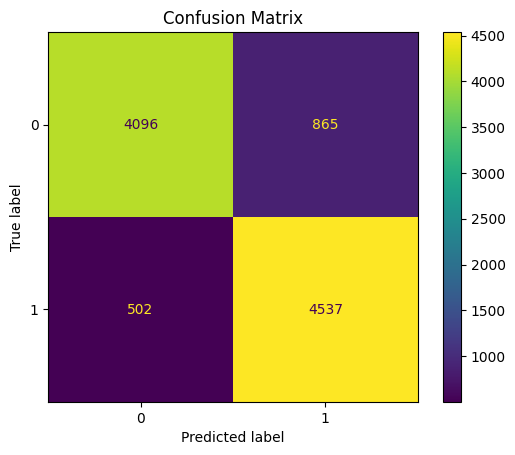

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

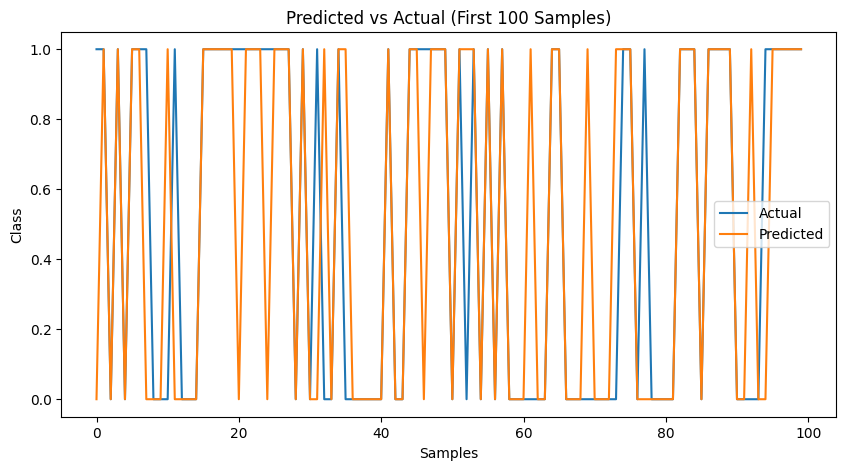

In [17]:
plt.figure(figsize=(10,5))

# Plot actual values
plt.plot(y_test.values[:100], label='Actual')

# Plot predicted values
plt.plot(y_pred[:100], label='Predicted')

plt.title('Predicted vs Actual (First 100 Samples)')
plt.xlabel('Samples')
plt.ylabel('Class')
plt.legend()
plt.show()

In [18]:
# STEP 11: Metrics Calculation
# -------------------------------

# Accuracy using sklearn
acc = accuracy_score(y_test, y_pred)

# MAE
mae_val = mean_absolute_error(y_test, y_pred)

print("\nSklearn Accuracy:", acc)
print("Sklearn MAE:", mae_val)


Sklearn Accuracy: 0.8633
Sklearn MAE: 0.1367


In [19]:
# -------------------------------
# USER INPUT PREDICTION
# -------------------------------

user_input = input("Enter a movie review: ")

# Preprocess input same as training data
user_seq = tokenizer.texts_to_sequences([user_input])
user_pad = pad_sequences(user_seq, maxlen=max_len)

# Predict
prediction = model.predict(user_pad)[0][0]

# Output result
if prediction > 0.5:
    print("Predicted Sentiment: Positive 😊")
else:
    print("Predicted Sentiment: Negative 😠")

print("Confidence Score:", prediction)

Enter a movie review: Worst movie ever, complete waste of time
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted Sentiment: Negative 😠
Confidence Score: 6.4566675e-06


In [20]:
# -------------------------------
# USER INPUT PREDICTION
# -------------------------------

user_input = input("Enter a movie review: ")

# Preprocess input same as training data
user_seq = tokenizer.texts_to_sequences([user_input])
user_pad = pad_sequences(user_seq, maxlen=max_len)

# Predict
prediction = model.predict(user_pad)[0][0]

# Output result
if prediction > 0.5:
    print("Predicted Sentiment: Positive 😊")
else:
    print("Predicted Sentiment: Negative 😠")

print("Confidence Score:", prediction)

Enter a movie review: This movie was amazing, I loved the acting and story
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Predicted Sentiment: Positive 😊
Confidence Score: 0.9944956
